In [ ]:
#%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

divorce = pd.read_csv("../datasets/divorce.csv", parse_dates=['divorce_date', 'dob_man', 'dob_woman', 'marriage_date'])

# Patterns over time
- Using dataset about divorce filings in Mexico
    - Whoops, I was ahead of the curve. Passing parse_dates was a later step lol.
- Can update datatypes using `df["col"] = pd.to_datetime(df["col"])` after import

In [2]:
print(divorce.head())
print(divorce.dtypes)


  divorce_date    dob_man education_man  income_man  dob_woman  \
0   2006-09-06 1975-12-18     Secondary      2000.0 1983-08-01   
1   2008-01-02 1976-11-17  Professional      6000.0 1977-03-13   
2   2011-01-02 1969-04-06   Preparatory      5000.0 1970-02-16   
3   2011-01-02 1979-11-13     Secondary     12000.0 1981-05-13   
4   2011-01-02 1982-09-20  Professional      6000.0 1988-01-30   

  education_woman  income_woman marriage_date  marriage_duration  num_kids  
0       Secondary        1800.0    2000-06-26                5.0       1.0  
1    Professional        6000.0    2001-09-02                7.0       NaN  
2    Professional        5000.0    2000-02-02                2.0       2.0  
3       Secondary       12000.0    2006-05-13                2.0       NaN  
4    Professional       10000.0    2007-08-06                3.0       NaN  
divorce_date         datetime64[us]
dob_man              datetime64[us]
education_man                   str
income_man                  float

## Creating DateTime data
- Ex. If a df has separate month, day, and year columns, can convert to a single datetime value using `pd.to_datetime`
- Can extract parts of a full date using `dt.month`, `dt.day`, and `dt.year`

In [3]:
# Separate out datetime into columns
df = divorce["divorce_date"].astype(str).str.split('-', expand=True)
df.columns = ["year","month","day"]

# Recondense into a single datetime
df["date"] = pd.to_datetime(df[["year","month","day"]])
print(df.head())

   year month day       date
0  2006    09  06 2006-09-06
1  2008    01  02 2008-01-02
2  2011    01  02 2011-01-02
3  2011    01  02 2011-01-02
4  2011    01  02 2011-01-02


## Visualizing patterns over time
- Use `sns.lineplot(data=df, x="time", y="variable")`

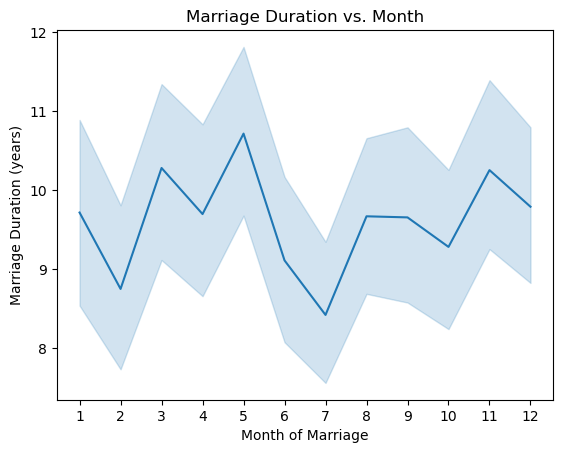

In [4]:
divorce["marriage_month"] = divorce["divorce_date"].dt.month
sns.lineplot(data=divorce, x="marriage_month", y="marriage_duration")
plt.xlabel("Month of Marriage")
plt.ylabel("Marriage Duration (years)")
plt.title("Marriage Duration vs. Month")
plt.xticks(range(1,13))
plt.show()

# Correlation

- Quick way to see pairwise correlations of *all* numeric variables in a dataframe is `df.corr(numeric_only=True)`

In [5]:
divorce.corr(numeric_only=True)

,income_man,income_woman,marriage_duration,num_kids,marriage_month
income_man,1.000000,0.318047,0.085321,0.040848,0.007414
income_woman,0.318047,1.000000,0.078677,-0.018015,0.017973
marriage_duration,0.085321,0.078677,1.000000,0.447358,0.005055
num_kids,0.040848,-0.018015,0.447358,1.000000,-0.023958
marriage_month,0.007414,0.017973,0.005055,-0.023958,1.000000


## Correlation heatmaps
- Can quickly visualize correlation using `sns.heatmap(df.corr(numeric_only=True),annot=True)`
- Important to compliment correlation calculations with scatterplots to identify if linear model is actually appropriate
- Can plot all pairwise relationships using `sns.pairplot(data=df, vars=[list of variables of interest])`

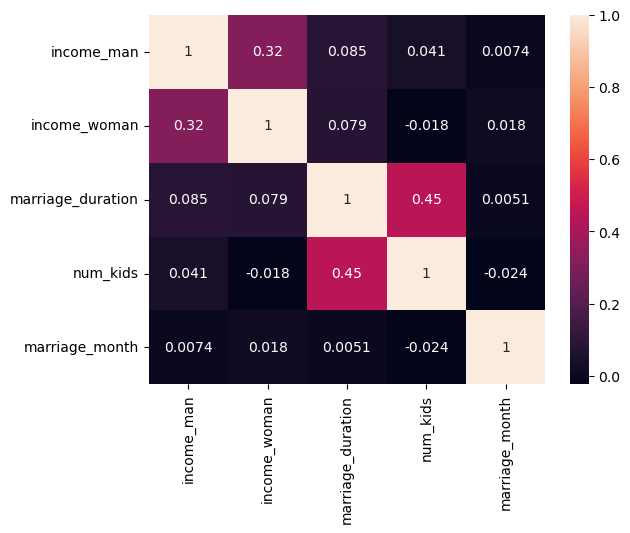

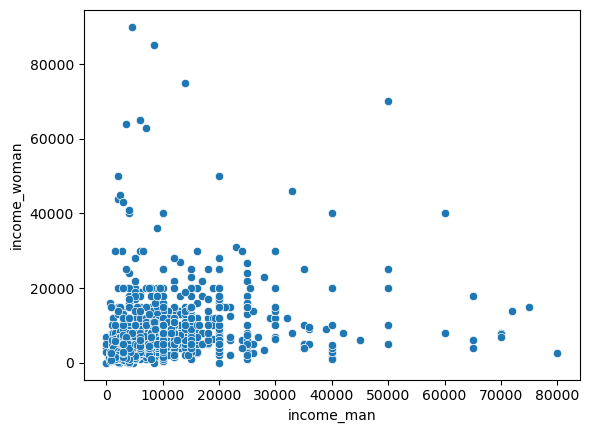

In [6]:
sns.heatmap(divorce.corr(numeric_only=True), annot=True)
plt.show()

sns.scatterplot(data=divorce, x="income_man", y="income_woman")
plt.show()

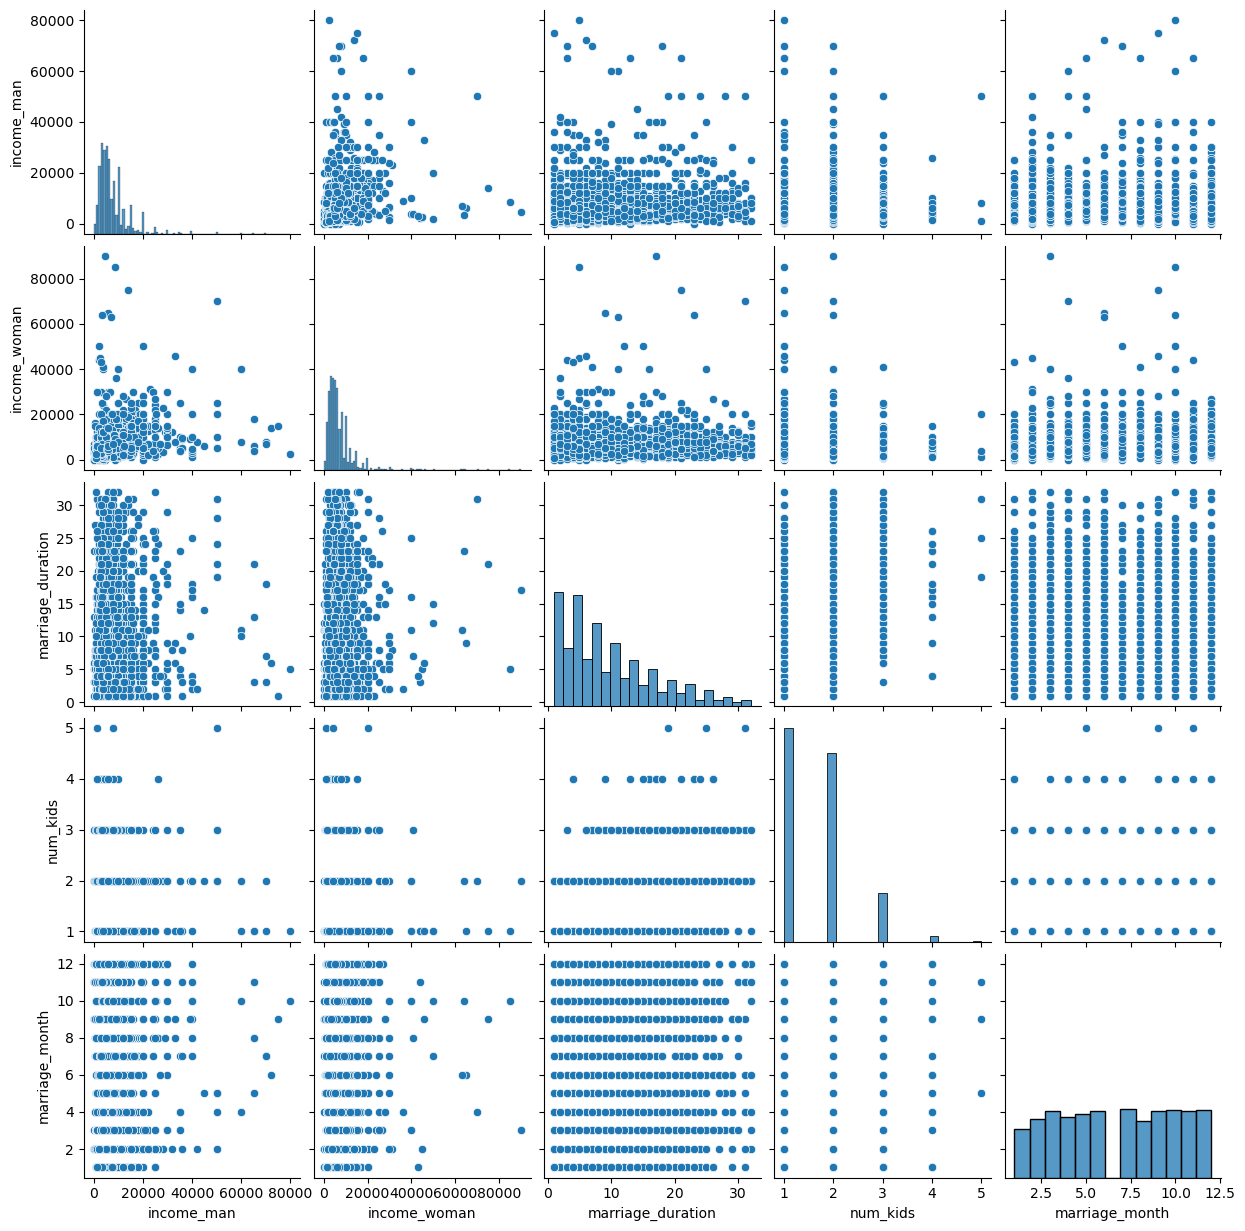

In [7]:
sns.pairplot(data=divorce)
plt.show()

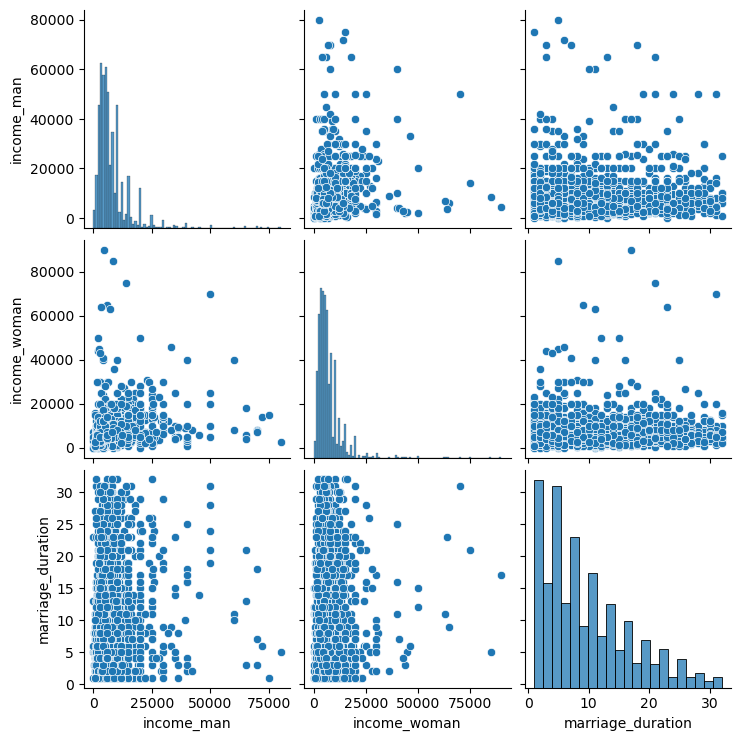

In [8]:
sns.pairplot(data=divorce, vars=["income_man","income_woman","marriage_duration"])
plt.show()

# Factor relationships and distributions
- Categorical variables (factors) also have relatiionships
- Reminder: use `df['col'].value_counts()` to find the frequency distribution of a categorical variable

In [9]:
divorce["education_man"].value_counts()

education_man
Professional    1313
Preparatory      501
Secondary        288
Primary          100
Other              3
Name: count, dtype: int64

## Exploring categorical relationships
- Use `sns.histplot(data=df, x="col")` for a rough distribution
    - Add dimensions to a histogram using hue
- Use `sns.kdeplot(data=df, x="col", hue="col2")` to explore relationship between frequency of col and categorical variable col2 using a density plot
    - KDE plots are considered more interpretable than stacked histograms
    - Use `cut` kwarg to limit curve when smoothing is applied. `cut=0` specifies the curve ends at min and max of var
    - Use `cumulative=True` kwarg to visualize cumulative distribution -> Requires import of scipy, apparently?

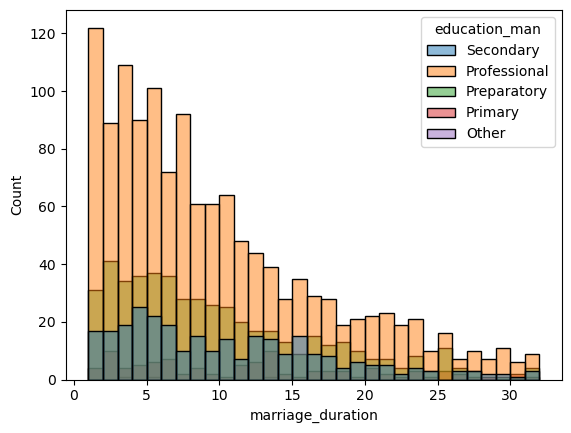

In [10]:
sns.histplot(data=divorce, x="marriage_duration", hue="education_man", binwidth=1)
plt.show()

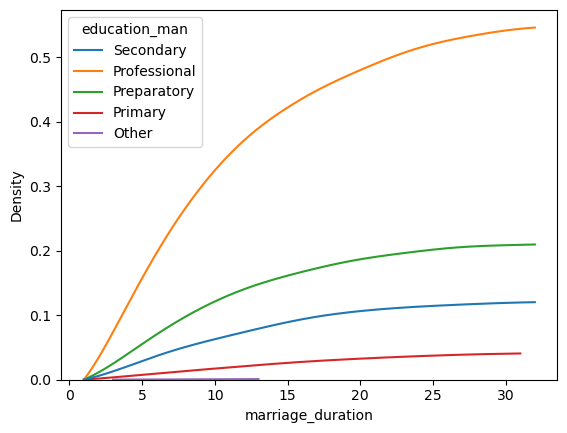

In [11]:
sns.kdeplot(data=divorce, x="marriage_duration", hue="education_man", cut=0, cumulative=True)
plt.show()

## Relationship between marriage age and education
- Is there a relationship between age at marriage and education level?

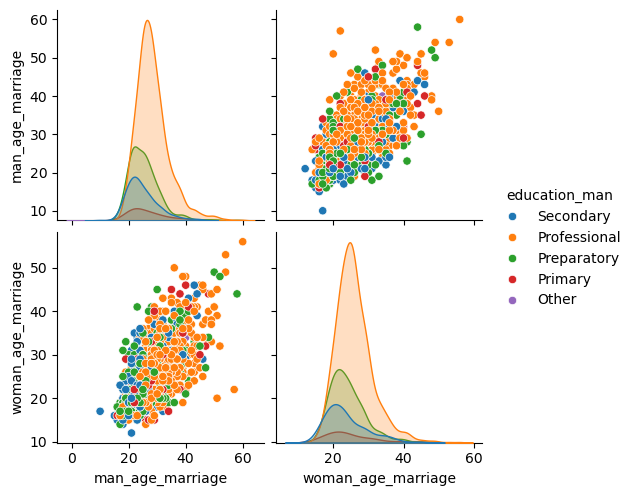

In [14]:
divorce["man_age_marriage"] = divorce["marriage_date"].dt.year - divorce["dob_man"].dt.year
divorce["woman_age_marriage"] = divorce["marriage_date"].dt.year - divorce["dob_woman"].dt.year

sns.pairplot(data=divorce, vars=["man_age_marriage","woman_age_marriage"], hue="education_man")
plt.show()